# The GP Engine — exact Gaussian-process regression at consumer-GPU scale

**What this is:** an engine for *exact* GP regression (fit, log-marginal-likelihood,
hyperparameter optimization, prediction with uncertainty) on dense RBF kernel
matrices, built for consumer GPUs. The solver core is CUDA Fortran
(`gp_solver.so`); this notebook drives it through the thin Python wrapper in
`gp_engine.py`. On an RTX 4060 8 GB it fits **n = 27,000 in 2.5 s** (12.6×
faster than FP64 cuSOLVER) and **n = 40,000** where FP64 cannot even allocate.

**The trick, in one sentence:** kernel matrices are too ill-conditioned for FP32
alone but FP64 runs at 1/64 rate on consumer silicon — so factor in FP32 at
tensor-class speed, then recover FP64 accuracy with a few cheap iterative-
refinement (IR) steps whose residuals are computed by **regenerating K on the
fly from X** (n×d, a few MB). The n×n kernel matrix is never stored in FP64.

**What CuPy gives you vs what this adds** — CuPy is the substrate here, not the
competition. But *stock* CuPy offers exactly two precision strategies for a
dense SPD solve, and both fail this workload:

| | stock CuPy FP32 | stock CuPy FP64 | this engine |
|---|---|---|---|
| speed on consumer GPU | fast | **1/64 rate** | fast (FP32 factor) |
| kernel conditioning (κ ~ 1e5–1e7) | **silent garbage** | fine | fine (IR to 1e-11) |
| memory for the factor | 4n² | 8n² (+copy in `cp.linalg.cholesky`) | 4n², K itself never stored |
| log-determinant (for LML) | — | manual | free from the factor |
| failure at extreme κ | **silent NaNs** | n/a | **detectable** (`FactorError`) |

Everything below runs live in a couple of minutes. See `README.md` for how this
engine relates to the Tensor Core Engine and MPDOK, and for the out-of-core
results (n up to 200,000) whose module ships in a later release.

In [1]:
import math, time, warnings
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import cupyx.scipy.linalg as cpx

from gp_engine import (RBFKernel, gp_fit, gp_predict, spd_factor_inplace,
                       potrs_inplace, FactorError)

# --- chart tokens (validated default palette; fixed slot order) ---
C1, C2, C3 = "#2a78d6", "#1baf7a", "#eda100"          # blue aqua yellow
INK, INK2, GRID = "#1a1a19", "#6f6e66", "#e8e7e0"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.75,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2,
    "font.size": 11, "axes.titlesize": 12, "axes.titlecolor": INK,
    "lines.linewidth": 2, "legend.frameon": False,
})

def sync(): cp.cuda.Device().synchronize()
def free(): cp.get_default_memory_pool().free_all_blocks()
def bench(fn, reps=1):
    fn(); sync()
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    sync()
    return (time.perf_counter() - t0) / reps

dev = cp.cuda.runtime.getDeviceProperties(0)
print(f"GPU: {dev['name'].decode()}  |  VRAM {dev['totalGlobalMem']/1e9:.1f} GB  |  CuPy {cp.__version__}")

def make_data(n, d=3, sigma_n=0.1, seed=0):
    rng = np.random.default_rng(seed)
    X = cp.asarray(rng.uniform(0.0, 1.0, (n, d)))
    f = cp.sin(3*X[:,0]) * cp.cos(2*X[:,1]) + 0.5*X[:,2 % d]**2
    return X, f + sigma_n*cp.asarray(rng.standard_normal(n))

GPU: NVIDIA GeForce RTX 4060  |  VRAM 8.2 GB  |  CuPy 13.6.0


## 1. Why stock FP32 can't do this (and FP64 shouldn't have to)

An RBF kernel matrix `K + σₙ²I` has condition number κ ≈ λ_max/σₙ² — routinely
1e5–1e7 for real data. Single-precision Cholesky loses ~κ·ε₃₂ of accuracy and
CuPy won't even tell you when it breaks. Watch stock FP32 fail *silently* while
the engine either succeeds or refuses *loudly*:

In [2]:
n = 4000
X, y = make_data(n)
kern_hard = RBFKernel(ell=0.3, sigma_f=1.0, sigma_n2=1e-6)   # kappa ~ 1e9: brutal
kern_real = RBFKernel(ell=0.3, sigma_f=1.0, sigma_n2=1e-2)   # kappa ~ 1e5: realistic

K64 = cp.empty((n, n), dtype=cp.float64, order="F")
kern_hard.build(X, K64)
L32 = cp.linalg.cholesky(K64.astype(cp.float32))   # no exception raised...
a = cpx.solve_triangular(L32, y.astype(cp.float32), lower=True)
a = cpx.solve_triangular(L32, a, lower=True, trans="T").astype(cp.float64)
rel = float(cp.linalg.norm(kern_hard.matvec(X, a) - y) / cp.linalg.norm(y))
print(f"stock FP32 cholesky at kappa~1e9: returns without error; "
      f"solve relres = {rel:.1e}  <- SILENTLY unusable")
del K64, L32, a; free()

try:
    gp_fit(kern_hard, X, y)
except FactorError:
    print("engine at kappa~1e9: fails DETECTABLY -> FactorError (fall back: "
          "bigger nugget, or FP64 where it fits)")

fit = gp_fit(kern_real, X, y)
print(f"engine at realistic kappa~1e5: relres {fit.relres:.1e} in {fit.n_ir} "
      f"IR steps (FP64-class accuracy from an FP32 factor)")

stock FP32 cholesky at kappa~1e9: returns without error; solve relres = nan  <- SILENTLY unusable
engine at kappa~1e9: fails DETECTABLY -> FactorError (fall back: bigger nugget, or FP64 where it fits)
engine at realistic kappa~1e5: relres 1.9e-12 in 5 IR steps (FP64-class accuracy from an FP32 factor)


## 2. Head-to-head at n = 12,000: engine vs CuPy FP64

Two FP64 baselines, to be scrupulously fair:

- **idiomatic CuPy** — what you'd actually write: build K with einsum/broadcast
  ops, `cp.linalg.cholesky` (which copies — 16n² transient!), two triangular
  solves, logdet from the diagonal;
- **engine-built K, FP64 factor** — we hand CuPy *our own* fused K builder, so
  the only difference left is the precision strategy of the factorization.

In [3]:
n = 12000
X, y = make_data(n)
kern = RBFKernel(ell=0.3, sigma_f=1.0, sigma_n2=1e-2)

def idiomatic_cupy_fp64():
    Xsq = cp.einsum("ij,ij->i", X, X)
    d2 = Xsq[:,None] + Xsq[None,:] - 2.0*(X @ X.T)
    K = cp.exp(-cp.maximum(d2, 0)/(2*0.3**2)) + 1e-2*cp.eye(n)
    L = cp.linalg.cholesky(K)
    a = cpx.solve_triangular(L, y, lower=True)
    alpha = cpx.solve_triangular(L, a, lower=True, trans="T")
    logdet = 2*float(cp.log(cp.diagonal(L)).sum())
    return alpha, logdet

def enginebuilt_fp64():
    K = cp.empty((n, n), dtype=cp.float64, order="F")
    kern.build(X, K)                    # our fused builder, FP64 output
    L = cp.linalg.cholesky(K)
    a = cpx.solve_triangular(L, y, lower=True)
    alpha = cpx.solve_triangular(L, a, lower=True, trans="T")
    return alpha, 2*float(cp.log(cp.diagonal(L)).sum())

t_idio = bench(lambda: idiomatic_cupy_fp64()); free()
t_ours = bench(lambda: enginebuilt_fp64());    free()
t_eng  = bench(lambda: gp_fit(kern, X, y));    free()

a_idio, ld_idio = idiomatic_cupy_fp64(); free()
fit = gp_fit(kern, X, y)
relres_idio = float(cp.linalg.norm(kern.matvec(X, a_idio) - y)/cp.linalg.norm(y))

print(f"{'path':26s} {'time':>8s} {'speedup':>8s} {'relres':>9s}   logdet")
print(f"{'idiomatic CuPy FP64':26s} {t_idio:7.2f}s {'1.0x':>8s} {relres_idio:9.1e}   {ld_idio:+.2f}")
print(f"{'engine-built K, FP64 factor':26s} {t_ours:7.2f}s {t_idio/t_ours:7.1f}x {'':9s}   (build was not the problem)")
print(f"{'engine (FP32 factor + IR)':26s} {t_eng:7.2f}s {t_idio/t_eng:7.1f}x {fit.relres:9.1e}   {fit.logdet:+.2f}")
print(f"\nlogdet bias vs FP64: {abs(fit.logdet-ld_idio):.2f} nats "
      f"(FP32 rounding of K; measured harmless for hyperparameter ranking)")
del a_idio, fit; free()

path                           time  speedup    relres   logdet
idiomatic CuPy FP64           3.00s     1.0x   1.4e-12   -54307.64
engine-built K, FP64 factor    2.94s     1.0x             (build was not the problem)
engine (FP32 factor + IR)     0.35s     8.6x   2.6e-12   -54305.06

logdet bias vs FP64: 2.58 nats (FP32 rounding of K; measured harmless for hyperparameter ranking)


## 3. Where the speedup comes from — and where FP64 simply stops

FP64 on consumer GPUs runs at **1/64** the FP32 rate, and `dpotrf` hits that
wall exactly. The engine's FP32 factorization runs ~30× faster, and the IR
overhead is a handful of fused implicit-K passes. The FP64 line also *ends*:
`cp.linalg.cholesky`'s copy needs 16n² bytes transiently, and even copy-free
FP64 dies near n≈27k on 8 GB — the engine's 4n² continues to n = 40,000.

In [4]:
ns_fp64 = [2000, 4000, 8000, 16000]
ns_eng  = [2000, 4000, 8000, 16000, 24000, 32000, 40000]
kern = RBFKernel(ell=0.3, sigma_f=1.0, sigma_n2=1e-2)

t_fp64, t_eng = [], []
for n in ns_fp64:
    X, y = make_data(n)
    def fp64():
        K = cp.empty((n, n), dtype=cp.float64, order="F")
        kern.build(X, K)
        L = cp.linalg.cholesky(K)
        a = cpx.solve_triangular(L, y, lower=True)
        cpx.solve_triangular(L, a, lower=True, trans="T")
    t_fp64.append(bench(fp64)); del X, y; free()
for n in ns_eng:
    X, y = make_data(n)
    t_eng.append(bench(lambda: gp_fit(kern, X, y))); del X, y; free()
    print(f"n={n:6d}  engine {t_eng[-1]:6.2f}s" +
          (f"   fp64 {t_fp64[ns_fp64.index(n)]:6.2f}s" if n in ns_fp64 else ""))

n=  2000  engine   0.01s   fp64   0.03s
n=  4000  engine   0.04s   fp64   0.14s
n=  8000  engine   0.20s   fp64   0.94s
n= 16000  engine   0.78s   fp64   6.76s
n= 24000  engine   1.81s
n= 32000  engine   4.02s
n= 40000  engine   6.55s


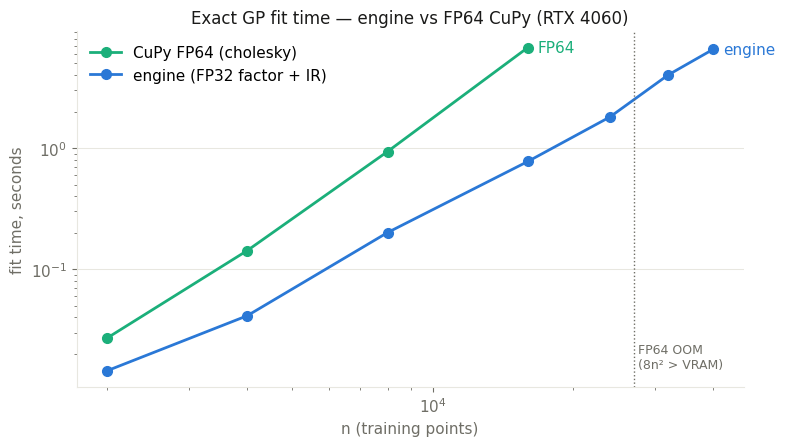

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(ns_fp64, t_fp64, color=C2, marker="o", ms=7, label="CuPy FP64 (cholesky)")
ax.plot(ns_eng, t_eng, color=C1, marker="o", ms=7, label="engine (FP32 factor + IR)")
ax.set(xscale="log", yscale="log", xlabel="n (training points)",
       ylabel="fit time, seconds",
       title="Exact GP fit time — engine vs FP64 CuPy (RTX 4060)")
ax.axvline(27000, color=INK2, lw=1, ls=":")
ax.text(27500, t_eng[0], "FP64 OOM\n(8n² > VRAM)", color=INK2, fontsize=9, va="bottom")
ax.text(ns_fp64[-1]*1.05, t_fp64[-1], "FP64", color=C2, va="center")
ax.text(ns_eng[-1]*1.05, t_eng[-1], "engine", color=C1, va="center")
ax.legend(loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 4. Iterative refinement, watched step by step

Each IR step: solve against the FP32 factor (cheap), then compute the residual
`r = y − Kα` in FP64 **with K regenerated from X by one fused kernel** — one
memory pass, no stored matrix. Convergence rate is ~κ·ε₃₂ per step, which makes
the engine's operating envelope visible: a real noise nugget converges in a few
steps; raise κ and IR slows — and past the envelope, the factor itself fails,
**loudly**, never silently.

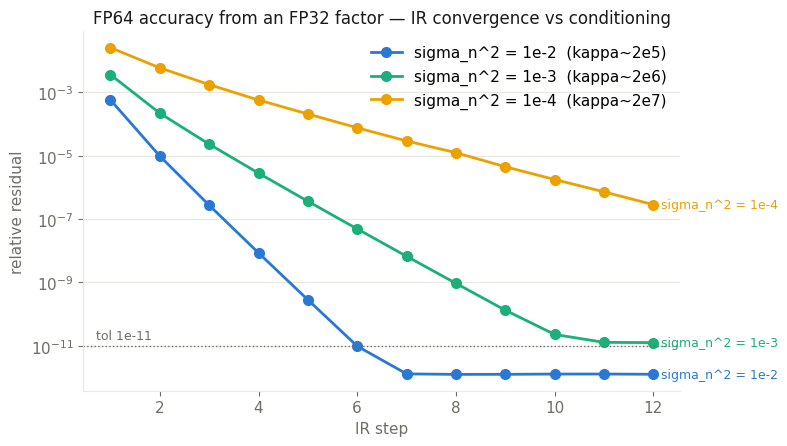

In [6]:
n = 8000
X, y = make_data(n)
traces = {}
for s2, label in [(1e-2, "sigma_n^2 = 1e-2  (kappa~2e5)"),
                  (1e-3, "sigma_n^2 = 1e-3  (kappa~2e6)"),
                  (1e-4, "sigma_n^2 = 1e-4  (kappa~2e7)")]:
    kern = RBFKernel(ell=0.3, sigma_f=1.0, sigma_n2=s2)
    K32 = cp.empty((n, n), dtype=cp.float32, order="F")
    kern.build(X, K32); spd_factor_inplace(K32)
    ynorm = float(cp.linalg.norm(y))
    alpha, r, hist = cp.zeros(n, cp.float64), y.copy(), []
    for _ in range(12):
        rn = float(cp.linalg.norm(r))
        r32 = (r/rn).astype(cp.float32); potrs_inplace(K32, r32)
        alpha += rn*r32.astype(cp.float64)
        r = y - kern.matvec(X, alpha)
        hist.append(float(cp.linalg.norm(r))/ynorm)
        if hist[-1] < 1e-13: break
    traces[label] = hist
    del K32; free()

fig, ax = plt.subplots(figsize=(8, 4.6))
for (label, hist), c in zip(traces.items(), [C1, C2, C3]):
    ax.plot(range(1, len(hist)+1), hist, color=c, marker="o", ms=7, label=label)
    ax.text(len(hist)+0.15, hist[-1], label.split("(")[0].strip(), color=c,
            fontsize=9, va="center")
ax.axhline(1e-11, color=INK2, lw=1, ls=":")
ax.text(0.7, 1.6e-11, "tol 1e-11", color=INK2, fontsize=9)
ax.set(yscale="log", xlabel="IR step", ylabel="relative residual",
       title="FP64 accuracy from an FP32 factor — IR convergence vs conditioning")
ax.legend(loc="upper right"); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 5. The hyperparameter loop — where the engine earns its keep

Fitting ℓ, σ_f, σ_n means maximizing the log marginal likelihood — a **fresh
factorization per candidate θ**, with the log-determinant returned free from
each factor. Derivative-free optimization keeps the factor as the only O(n³)
object; out-of-envelope candidates return a penalty, so the optimizer routes
around the κ wall on its own. (Measured at n=27k on this card: an 80-eval fit
in 2.8 min vs ~41 min for FP64.)

In [7]:
from scipy.optimize import minimize
n = 8000
X, y = make_data(n, sigma_n=0.1)
LOG2PI = math.log(2*math.pi)
eval_times = []

def neg_lml(logp):
    ell, sigf, sign = np.exp(logp)
    kern = RBFKernel(ell, sigf, sign**2)
    t0 = time.perf_counter()
    try:
        fit = gp_fit(kern, X, y, tol=1e-8)
        lml = -0.5*float(y @ fit.alpha) - 0.5*fit.logdet - 0.5*n*LOG2PI
        if fit.relres > 1e-3:
            lml = -1e12                       # IR broke down: out of envelope
    except FactorError:
        lml = -1e12                           # kappa wall: not SPD in FP32
    eval_times.append(time.perf_counter() - t0)
    return -lml

ystd = float(cp.std(y))
t0 = time.perf_counter()
r = minimize(neg_lml, np.log([0.2, ystd, 0.3*ystd]), method="Nelder-Mead",
             options=dict(maxfev=30, xatol=1e-2, fatol=0.25))
wall = time.perf_counter() - t0
ell, sigf, sign = np.exp(r.x)

def fp64_lml_once():
    kern = RBFKernel(ell, sigf, sign**2)
    K = cp.empty((n, n), dtype=cp.float64, order="F")
    kern.build(X, K)
    L = cp.linalg.cholesky(K)
    a = cpx.solve_triangular(L, y, lower=True)
    a = cpx.solve_triangular(L, a, lower=True, trans="T")
    return -0.5*float(y @ a) - float(cp.log(cp.diagonal(L)).sum()) - 0.5*n*LOG2PI
t_f64 = bench(fp64_lml_once); free()

print(f"recovered: ell={ell:.3f}  sigma_f={sigf:.3f}  sigma_n={sign:.4f} "
      f"(true 0.1)   LML={-r.fun:.1f}")
print(f"{r.nfev} evals in {wall:.1f}s -> {np.mean(eval_times):.2f}s/eval "
      f"(FP64 objective: {t_f64:.2f}s/eval -> {t_f64/np.mean(eval_times):.1f}x per eval)")

recovered: ell=0.585  sigma_f=0.332  sigma_n=0.0998 (true 0.1)   LML=6912.2
30 evals in 4.0s -> 0.13s/eval (FP64 objective: 0.94s/eval -> 7.0x per eval)


## 6. Prediction with honest uncertainty

Mean via one fused cross-kernel pass (`K*ᵀα`, exact given α); variance via
batched FP32 triangular solves against the factor kept from the fit — the
"factor once, solve many" pattern. Variance error vs dense FP64: ~6e-6,
three orders below the noise floor.

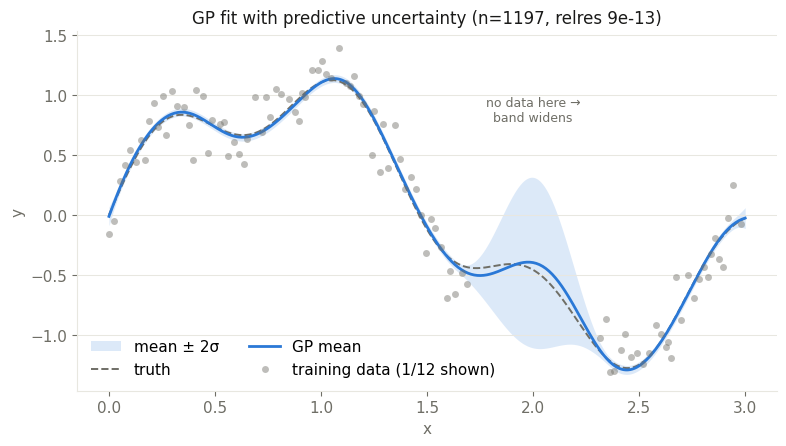

In [8]:
rng = np.random.default_rng(3)
n1 = 1500
X1 = cp.asarray(np.sort(rng.uniform(0, 3, (n1, 1)), axis=0))
f_true = lambda x: cp.sin(2*x) + 0.3*cp.sin(7*x)
y1 = f_true(X1[:,0]) + 0.15*cp.asarray(rng.standard_normal(n1))
keep = ((X1[:,0] < 1.7) | (X1[:,0] > 2.3)).get()   # leave a gap: honest bands
X1, y1 = X1[keep], y1[keep]

kern1 = RBFKernel(ell=0.25, sigma_f=1.0, sigma_n2=0.15**2)
fit1 = gp_fit(kern1, X1, y1)
Xg = cp.linspace(0, 3, 400).reshape(-1, 1)
mean, var = gp_predict(fit1, kern1, X1, Xg)
sd = cp.sqrt(var)

xg, m, s = Xg[:,0].get(), mean.get(), sd.get()
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.fill_between(xg, m-2*s, m+2*s, color=C1, alpha=0.16, lw=0, label="mean ± 2σ")
ax.plot(xg, f_true(Xg[:,0]).get(), color=INK2, lw=1.4, ls="--", label="truth")
ax.plot(xg, m, color=C1, label="GP mean")
ax.plot(X1[:,0].get()[::12], y1.get()[::12], "o", ms=5, color=INK2, alpha=0.45,
        mec="none", label="training data (1/12 shown)")
ax.text(2.0, 0.78, "no data here →\nband widens", color=INK2, fontsize=9, ha="center")
ax.set(xlabel="x", ylabel="y", title=f"GP fit with predictive uncertainty "
       f"(n={int(keep.sum())}, relres {fit1.relres:.0e})")
ax.legend(loc="lower left", ncol=2); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
del fit1; free()

## 7. Beyond VRAM: the out-of-core results (module ships later)

Past n≈40k the FP32 factor outgrows VRAM. The engine's out-of-core mode keeps
the factor as panels tiered across pinned host RAM and NVMe (regenerating K
tiles on-GPU so the kernel matrix never crosses PCIe or touches a disk), with
double-buffered "ping-pong" streaming so transfers hide behind compute. That
module is **not part of this preview**; the measured results on the same
RTX 4060 desktop are:

| n | mode | fit + logdet | accuracy | footprint |
|---|---|---|---|---|
| 27,000 | in-core | 2.5 s (12.6× vs FP64) | 6e-12 | 3.5 GB VRAM |
| 40,000 | in-core | 6.5 s | 6e-12 | 7.0 GB VRAM |
| 60,000 | out-of-core | ~40 s | 2e-11 | 7.7 GB host RAM |
| 100,000 | out-of-core | 5.4 min | 3e-11 | 12 GB RAM + 9 GB NVMe |
| 200,000 | out-of-core | 71 min, converged | 3.4e-10 | 12 GB RAM + 70 GB NVMe |

At n=200k the kernel matrix would be **320 GB in FP64** — it never exists in
any precision; the remaining bottleneck at that scale is the SSD (~1 GB/s
through disk encryption), not the GPU.

## 8. What's under the hood

The solver core is **CUDA Fortran** (`gp_solver.so`, compiled for cc86/cc89 —
Ampere/Ada), in the same family style as the MPDOK mixed-precision solver and
the Tensor Core Engine (see `README.md` for the lineage). It exposes seven
entry points: fused RBF build (FP32/FP64), fused implicit-K matvec, two
prediction cross-kernels, and the FP32 SPD factorization with FP64
log-determinant plus its triangular solver. `gp_engine.py` adds ctypes
bindings, the IR loop, and the fit/predict API — ~250 lines of plain Python.
The port was validated **bit-identical** against an independent reference
implementation on build, factor, log-determinant, solves, and predictive
variance before release.

## 9. Honest limits (read before depending on it)

- **Operating envelope: κ(K+σₙ²I) ≲ 1e7** — GP regression *with a real noise
  nugget*, which is most real GP. Outside it the engine fails detectably
  (`FactorError` / `converged=False`), never silently.
- **logdet from the FP32 factor is biased ~2–5 nats** (FP32 rounding of K
  itself). Measured harmless for hyperparameter *selection* (100% rank
  agreement); refine at the optimum if you need absolute LML values.
- **RBF/SE kernel, d ≤ 16** in this preview.
- **Small n is not the use case** — under n≈2k, FP64 is already instant.
- Speedups quoted are consumer-GPU numbers (FP64 at 1/64 rate); on datacenter
  parts with 1:2 FP64 expect 3–5×, not 12×.
- At high κ, IR needs budget: convergence is ~κ·ε₃₂ per step (measured
  0.32×/step at κ≈8e6), so large-n / small-nugget fits want `tol=1e-9,
  max_ir≥16`.